In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle

In [2]:
df = pd.read_csv("demand_forecasting.csv")

In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [7]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [8]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [15]:
x = df[features].copy()

In [16]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [12]:
target = "Demand"

In [13]:
y = df[target]

In [14]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

For categorical Columns

In [17]:
label_encoder = {}

categorical_cols = x.select_dtypes(include="object").columns

In [18]:
categorical_cols

Index(['Category'], dtype='object')

In [19]:
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoder[col] = le

In [20]:
label_encoder

{'Category': LabelEncoder()}

Train Test split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

In [22]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [23]:
xgb = XGBRegressor(objective= "reg:squarederror", n_jobs = -1)

In [24]:
param_dict = {
    "n_estimators": [200,300,500],
    "max_depth": [3,4,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1.0],
    "colsample_bytree": [0.7,0.8,1.0],
    "min_child_weight": [1,3,5]
}

In [25]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions= param_dict,
    n_iter=25,
    scoring= "neg_mean_absolute_error",
    cv= 3,
    verbose= 1,
    n_jobs= -1
)

In [26]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [27]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [28]:
best_model = random_search.best_estimator_

In [30]:
y_pred = best_model.predict(x_test)

In [31]:
mean_squared_error(y_test, y_pred, squared=False)

35.4168504788129

In [32]:
best_model.feature_importances_

array([0.1212159 , 0.0705786 , 0.04475108, 0.36534268, 0.0542846 ,
       0.34382707], dtype=float32)

In [33]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending=False)

In [34]:
feature_importance

Promotion             0.365343
Category              0.343827
Price                 0.121216
Discount              0.070579
Competitor Pricing    0.054285
Inventory Level       0.044751
dtype: float32

<Axes: title={'center': 'Feature  Importances'}>

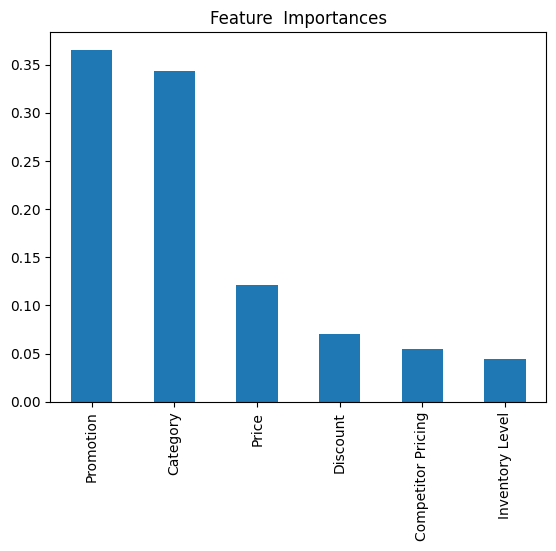

In [35]:
feature_importance.plot(kind="bar", title="Feature  Importances")

In [36]:
with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder, f)

In [37]:
with open("xgboost_demand_model.pkl","wb") as f:
    pickle.dump(best_model, f)